# UBA - CEIA - Análisis de Datos  (Azar Miguel Augusto)


---

# EDA - Superstore Dataset

Análisis exploratorio de datos (EDA) del dataset **Sample Superstore**
( https://www.kaggle.com/datasets/vivek468/superstore-dataset-final ).

Este notebook:
1. Descarga el dataset (mirror público en GitHub; opcionalmente vía API de Kaggle).
2. Calcula **estadística descriptiva completa** (tendencia central, dispersión y forma).
3. Clasifica los **tipos de variables**, incluyendo nominal/ordinal para las categóricas.
4. Analiza **relaciones entre variables**: covarianza, correlación de Pearson, Spearman y Kendall.
5. Genera gráficos **etiquetados según el tipo de relación que muestran**, mostrados por consola de Colab con `plt.show()`.


## 1. Configuración e instalación de librerías

In [49]:
!pip install -q pandas matplotlib seaborn scipy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110


## 2. Cargar el dataset

**Opción A (por defecto): descarga directa desde un mirror público en GitHub**
con la misma estructura del dataset de Kaggle (21 columnas, 9994 filas).

**Opción B: API oficial de Kaggle.** Se debe subir el `kaggle.json` (Kaggle > Account > Create
New API Token) y descomentar la celda de la Opción B.

In [50]:
# --- Opción A: mirror público en GitHub (activa por defecto) ---
DATA_URL = "https://raw.githubusercontent.com/sumit0072/Superstore-Data-Analysis/main/Sample%20-%20Superstore.csv"
df = pd.read_csv(DATA_URL, encoding="latin1")

# --- Opción B: API de Kaggle (descomentar para usar) ---
# !pip install -q kaggle
# from google.colab import files
# files.upload()  # subir kaggle.json cuando lo pida
# !mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
# !kaggle datasets download -d vivek468/superstore-dataset-final -p /content --unzip
# df = pd.read_csv("/content/Sample - Superstore.csv", encoding="latin1")

df["Order Date"] = pd.to_datetime(df["Order Date"], format="%m/%d/%Y")
df["Ship Date"] = pd.to_datetime(df["Ship Date"], format="%m/%d/%Y")

num_cols = ["Sales", "Quantity", "Discount", "Profit"]
cat_cols = ["Ship Mode", "Segment", "Region", "Category", "Sub-Category"]

print(df.shape)
df.head()


(9994, 21)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [51]:
print("Filas duplicadas:", df.duplicated().sum())
print("Valores nulos totales:", df.isna().sum().sum())
print("Rango de fechas:", df["Order Date"].min().date(), "-", df["Order Date"].max().date())


Filas duplicadas: 0
Valores nulos totales: 0
Rango de fechas: 2014-01-03 - 2017-12-30


## 3. Estadística descriptiva

### 3.1 Medidas de tendencia central, dispersión y forma (variables numéricas)

In [52]:
resumen_numerico = pd.DataFrame(index=num_cols)

# Tendencia central
resumen_numerico["media"] = df[num_cols].mean()
resumen_numerico["mediana"] = df[num_cols].median()
resumen_numerico["moda"] = df[num_cols].mode().iloc[0]

# Dispersión
resumen_numerico["varianza"] = df[num_cols].var()
resumen_numerico["desv_estandar"] = df[num_cols].std()
resumen_numerico["rango"] = df[num_cols].max() - df[num_cols].min()

# Forma
resumen_numerico["asimetria"] = df[num_cols].skew()                                  # Fisher-Pearson
resumen_numerico["curtosis_exceso"] = df[num_cols].kurtosis()                          # Fisher (normal = 0)
resumen_numerico["curtosis"] = resumen_numerico["curtosis_exceso"] + 3                  # Pearson (normal = 3)

resumen_numerico.round(3)


,media,mediana,moda,varianza,desv_estandar,rango,asimetria,curtosis_exceso,curtosis
Sales,229.858,54.490,12.96,388434.455,623.245,22638.036,12.973,305.312,308.312
Quantity,3.790,3.000,3.00,4.951,2.225,13.000,1.279,1.992,4.992
Discount,0.156,0.200,0.00,0.043,0.206,0.800,1.684,2.410,5.410
Profit,28.657,8.666,0.00,54877.798,234.260,14999.954,7.561,397.189,400.189


**Cómo interpretar:**
- `asimetria` > 0 implica cola larga hacia la derecha (valores extremos altos); < 0 implica cola hacia la izquierda.
- `curtosis_exceso` > 0 implica distribución más "puntiaguda" que la normal (leptocúrtica), con colas pesadas;
  < 0 implica más "achatada" (platicúrtica). `curtosis` es la misma medida pero en la escala de Pearson (normal = 3).

### 3.2 Variables categóricas: moda y tabla de frecuencias

In [53]:
for c in cat_cols:
    moda = df[c].mode()[0]
    freq = df[c].value_counts(normalize=True).round(3) * 100
    print(f"--- {c} (moda = '{moda}') ---")
    print(freq.to_string())
    print()


--- Ship Mode (moda = 'Standard Class') ---
Ship Mode
Standard Class    59.7
Second Class      19.5
First Class       15.4
Same Day           5.4

--- Segment (moda = 'Consumer') ---
Segment
Consumer       51.9
Corporate      30.2
Home Office    17.8

--- Region (moda = 'West') ---
Region
West       32.0
East       28.5
Central    23.2
South      16.2

--- Category (moda = 'Office Supplies') ---
Category
Office Supplies    60.3
Furniture          21.2
Technology         18.5

--- Sub-Category (moda = 'Binders') ---
Sub-Category
Binders        15.2
Paper          13.7
Furnishings     9.6
Phones          8.9
Storage         8.5
Art             8.0
Accessories     7.8
Chairs          6.2
Appliances      4.7
Labels          3.6
Tables          3.2
Envelopes       2.5
Bookcases       2.3
Fasteners       2.2
Supplies        1.9
Machines        1.2
Copiers         0.7



In [54]:
margen_global = df["Profit"].sum() / df["Sales"].sum() * 100
print(f"Margen de ganancia global: {margen_global:.2f} %")


Margen de ganancia global: 12.47 %


## 4. Tipos de variables

Se clasifican en: identificador, fecha, numérica continua, numérica discreta,
y categórica (indicando si es **nominal**, sin orden u **ordinal**, con orden).

In [55]:
tipos = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "n_unicos": df.nunique(),
    "n_nulos": df.isna().sum()
})

clasificacion_general = np.select(
    [
        tipos.index.isin(["Row ID", "Order ID", "Customer ID", "Product ID"]),
        tipos.index.isin(["Order Date", "Ship Date"]),
        tipos["dtype"] == "float64",
        (tipos["dtype"] == "int64") & (tipos.index != "Postal Code"),
    ],
    ["identificador", "fecha", "numerica_continua", "numerica_discreta"],
    default="categorica"
)
tipos["clasificacion"] = clasificacion_general
tipos.loc["Postal Code", "clasificacion"] = "identificador"  # codigo, no cantidad

# Escala nominal / ordinal solo aplica a las categóricas
escala_categorica = {
    "Ship Mode": "ordinal",       # Standard < Second < First < Same Day (orden de velocidad)
    "Segment": "nominal",
    "Country": "nominal",
    "City": "nominal",
    "State": "nominal",
    "Region": "nominal",
    "Category": "nominal",
    "Sub-Category": "nominal",
    "Product Name": "nominal",
    "Customer Name": "nominal",
}
tipos["escala_nominal_ordinal"] = tipos.index.map(escala_categorica)

tipos


,dtype,n_unicos,n_nulos,clasificacion,escala_nominal_ordinal
Row ID,int64,9994,0,identificador,NaN
Order ID,object,5009,0,identificador,NaN
Order Date,datetime64[ns],1237,0,fecha,NaN
Ship Date,datetime64[ns],1334,0,fecha,NaN
Ship Mode,object,4,0,categorica,ordinal
Customer ID,object,793,0,identificador,NaN
Customer Name,object,793,0,categorica,nominal
Segment,object,3,0,categorica,nominal
Country,object,1,0,categorica,nominal
City,object,531,0,categorica,nominal


**Nota sobre `Ship Mode`:** aunque es una variable de texto, tiene un orden lógico implícito
según la velocidad de envío (`Standard Class` < `Second Class` < `First Class` < `Same Day`),
por eso las clasifico como **ordinal**. El resto de las variables categóricas (Segment, Region,
Category, Sub-Category, nombres) son **nominales**: sus categorías no tienen un orden natural.

## 5. Relación entre variables

### 5.1 Covarianza

In [56]:
covarianza = df[num_cols].cov()
covarianza.round(2)


,Sales,Quantity,Discount,Profit
Sales,388434.46,278.46,-3.63,69944.10
Quantity,278.46,4.95,0.00,34.53
Discount,-3.63,0.00,0.04,-10.62
Profit,69944.10,34.53,-10.62,54877.80


### 5.2 Correlación de Pearson (relaciones lineales)

In [57]:
pearson = df[num_cols].corr(method="pearson")
pearson.round(3)


,Sales,Quantity,Discount,Profit
Sales,1.000,0.201,-0.028,0.479
Quantity,0.201,1.000,0.009,0.066
Discount,-0.028,0.009,1.000,-0.219
Profit,0.479,0.066,-0.219,1.000


### 5.3 Correlación de Spearman (relaciones monótonas, basada en rangos)

In [58]:
spearman = df[num_cols].corr(method="spearman")
spearman.round(3)


,Sales,Quantity,Discount,Profit
Sales,1.000,0.327,-0.057,0.518
Quantity,0.327,1.000,-0.001,0.234
Discount,-0.057,-0.001,1.000,-0.543
Profit,0.518,0.234,-0.543,1.000


### 5.4 Correlación de Kendall (basada en concordancia de pares, más robusta a outliers)

In [59]:
kendall = df[num_cols].corr(method="kendall")
kendall.round(3)


,Sales,Quantity,Discount,Profit
Sales,1.000,0.239,-0.042,0.452
Quantity,0.239,1.000,-0.001,0.172
Discount,-0.042,-0.001,1.000,-0.428
Profit,0.452,0.172,-0.428,1.000


### 5.5 Matriz de correlación (gráfico) — comparación Pearson / Spearman / Kendall

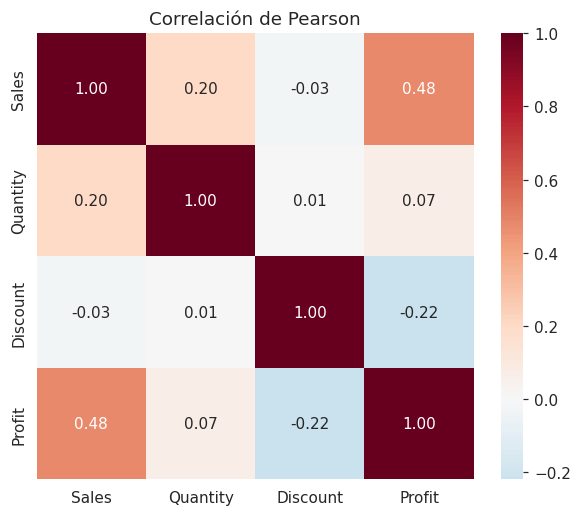

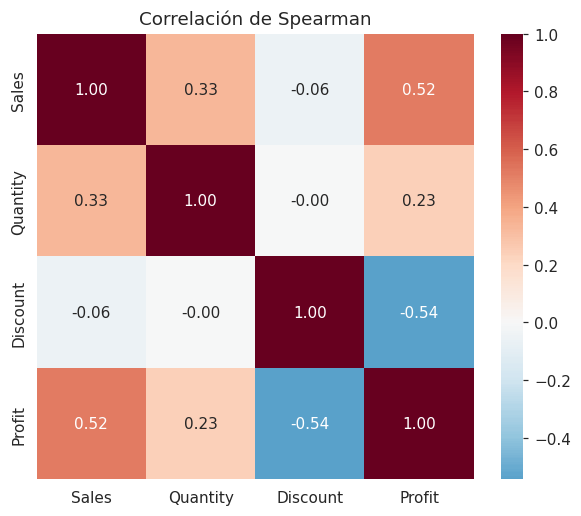

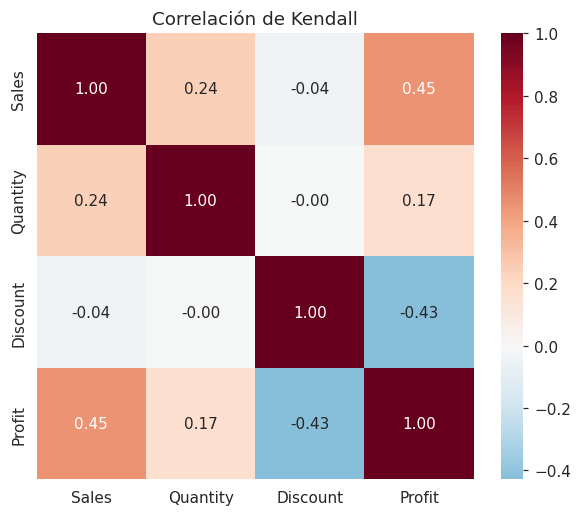

In [60]:
for nombre, matriz in [("Pearson", pearson), ("Spearman", spearman), ("Kendall", kendall)]:
    fig, ax = plt.subplots(figsize=(5.5, 4.8))
    sns.heatmap(matriz, annot=True, cmap="RdBu_r", center=0, fmt=".2f", ax=ax)
    ax.set_title(f"Correlación de {nombre}")
    plt.tight_layout()
    plt.show()


## 6. Gráficos exploratorios

Cada gráfico está etiquetado según el **tipo de relación** que representa.

### 6.1 Distribución de una variable numérica

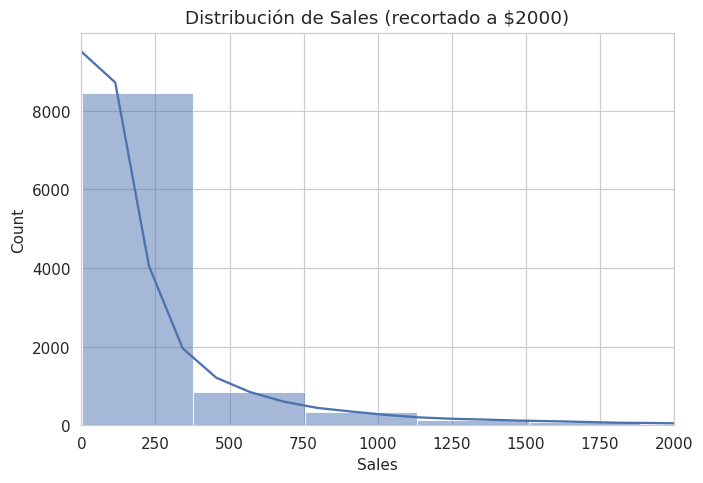

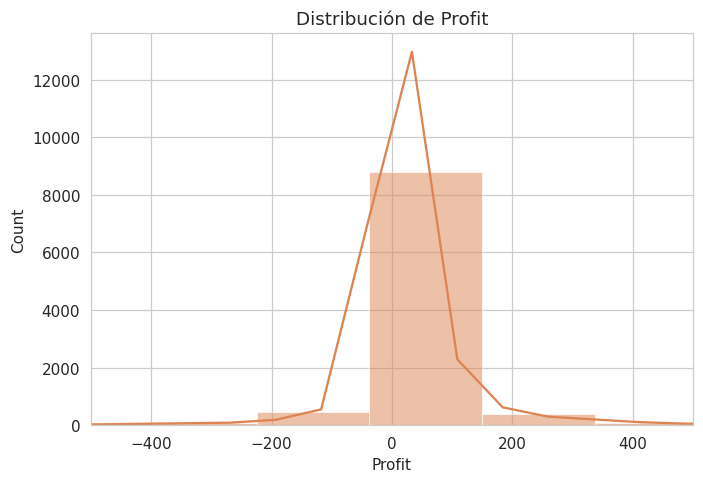

In [61]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
sns.histplot(df["Sales"], bins=60, kde=True, ax=ax, color="#4C72B0")
ax.set_xlim(0, 2000)
ax.set_title("Distribución de Sales (recortado a $2000)")
plt.tight_layout()
plt.show()
print("\n")
fig, ax = plt.subplots(figsize=(6.5, 4.5))
sns.histplot(df["Profit"], bins=80, kde=True, ax=ax, color="#DD8452")
ax.set_xlim(-500, 500)
ax.set_title("Distribución de Profit")
plt.tight_layout()
plt.show()

### 6.2 Distribución de una variable categórica

Muestro las 2 variables categóricas más relevantes para el análisis
(`Category` y `Region`); omito `Segment` y `Ship Mode` para no sobrecargar el notebook.

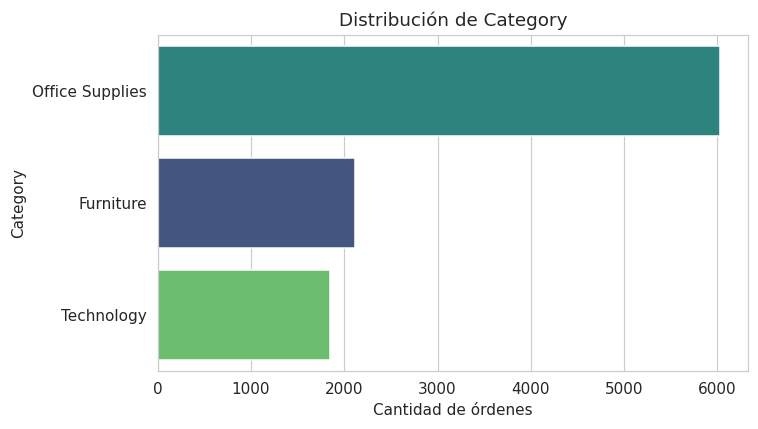

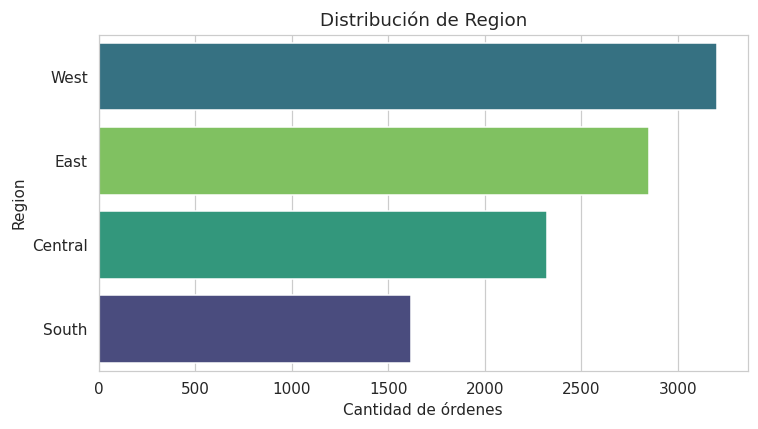

In [62]:
for col in ["Category", "Region"]:
    fig, ax = plt.subplots(figsize=(7, 4))
    orden = df[col].value_counts().index
    sns.countplot(data=df, y=col, order=orden, hue=col, palette="viridis", legend=False, ax=ax)
    ax.set_title(f"Distribución de {col}")
    ax.set_xlabel("Cantidad de órdenes")
    plt.tight_layout()
    plt.show()

### 6.3 Relación entre dos variables numéricas

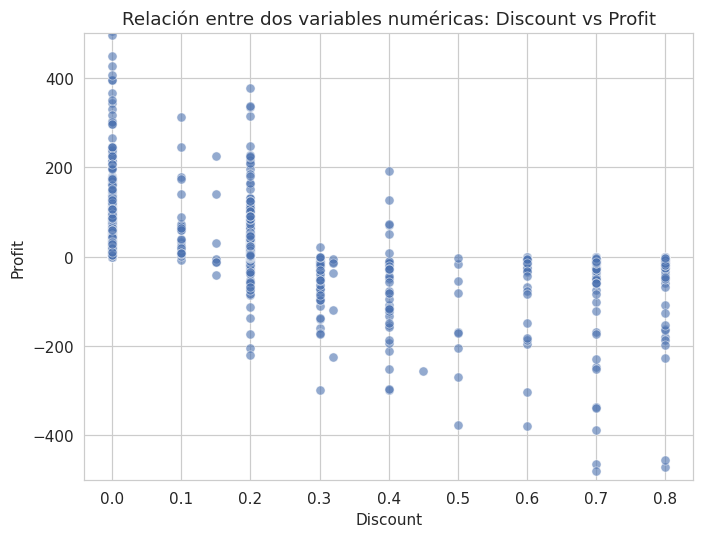

In [63]:
fig, ax = plt.subplots(figsize=(6.5, 5))
muestra = df.sample(2000, random_state=1)
sns.scatterplot(data=muestra, x="Discount", y="Profit", alpha=0.6, ax=ax, color="#4C72B0")
ax.set_ylim(-500, 500)
ax.set_title("Relación entre dos variables numéricas: Discount vs Profit")
plt.tight_layout()
plt.show()

### 6.4 Relación entre una variable numérica y una categórica

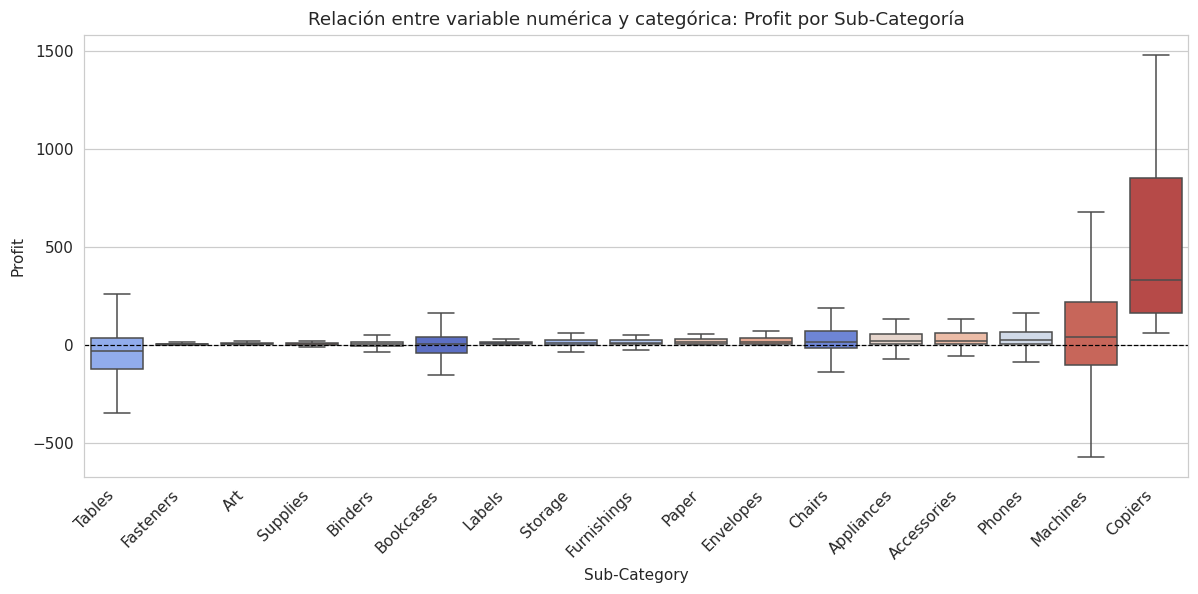

In [64]:
fig, ax = plt.subplots(figsize=(11, 5.5))
orden = df.groupby("Sub-Category")["Profit"].median().sort_values().index
sns.boxplot(data=df, x="Sub-Category", y="Profit", order=orden, showfliers=False,
            hue="Sub-Category", palette="coolwarm", legend=False, ax=ax)
ax.set_xticks(range(len(orden)))
ax.set_xticklabels(orden, rotation=45, ha="right")
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("Relación entre variable numérica y categórica: Profit por Sub-Categoría")
plt.tight_layout()
plt.show()

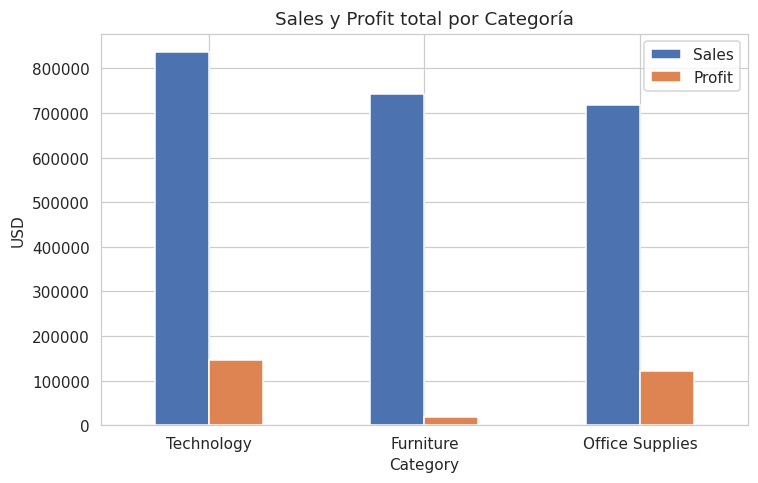

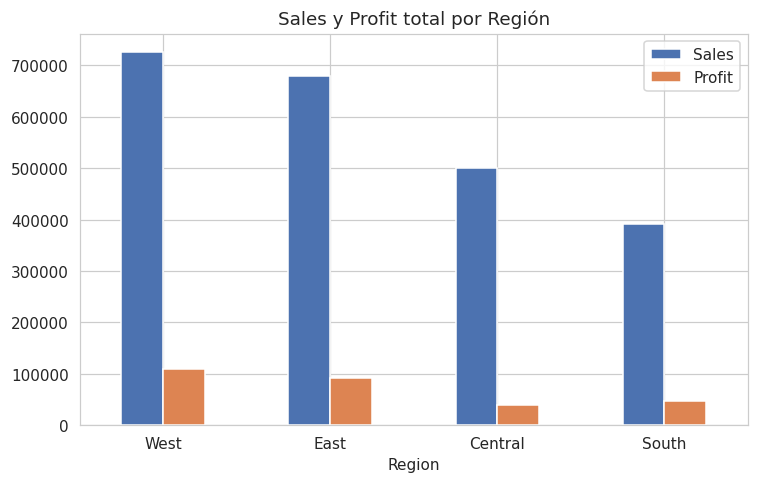

In [65]:
cat = df.groupby("Category")[["Sales", "Profit"]].sum().sort_values("Sales", ascending=False)
fig, ax = plt.subplots(figsize=(7, 4.5))
cat.plot(kind="bar", ax=ax, color=["#4C72B0", "#DD8452"])
ax.set_title("Sales y Profit total por Categoría")
ax.set_ylabel("USD")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()
print("\n")
reg = df.groupby("Region")[["Sales", "Profit"]].sum().sort_values("Sales", ascending=False)
fig, ax = plt.subplots(figsize=(7, 4.5))
reg.plot(kind="bar", ax=ax, color=["#4C72B0", "#DD8452"])
ax.set_title("Sales y Profit total por Región")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

### 6.5 Relación entre dos variables categóricas

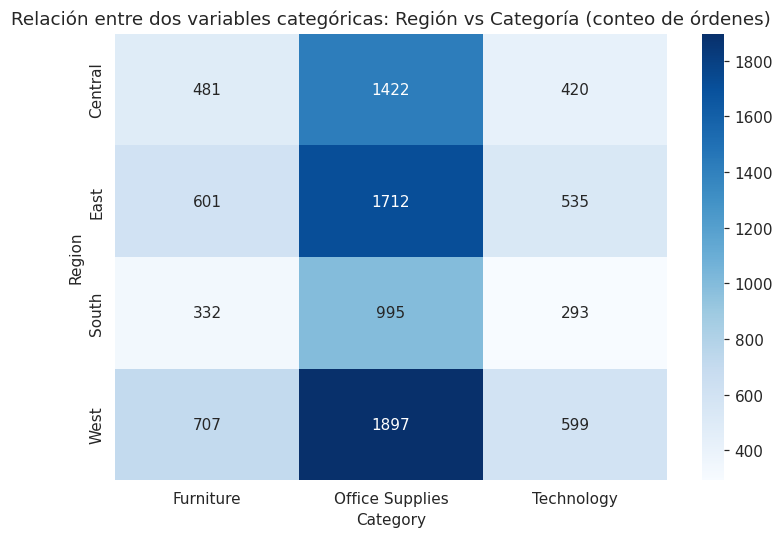

In [66]:
tabla_cruzada = pd.crosstab(df["Region"], df["Category"])
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(tabla_cruzada, annot=True, fmt="d", cmap="Blues", ax=ax)
ax.set_title("Relación entre dos variables categóricas: Región vs Categoría (conteo de órdenes)")
plt.tight_layout()
plt.show()

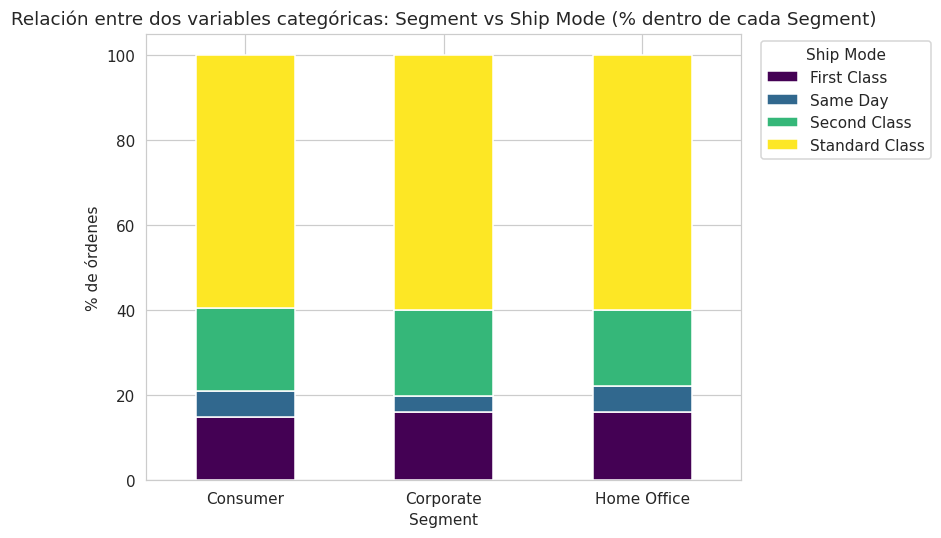

In [67]:
tabla_cruzada_norm = pd.crosstab(df["Segment"], df["Ship Mode"], normalize="index") * 100
fig, ax = plt.subplots(figsize=(8, 5))
tabla_cruzada_norm.plot(kind="bar", stacked=True, ax=ax, colormap="viridis")
ax.set_title("Relación entre dos variables categóricas: Segment vs Ship Mode (% dentro de cada Segment)")
ax.set_ylabel("% de órdenes")
ax.tick_params(axis="x", rotation=0)
ax.legend(title="Ship Mode", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### 6.6 Relaciones multivariadas

Muestro las 2 visualizaciones multivariadas que considero más relevantes.

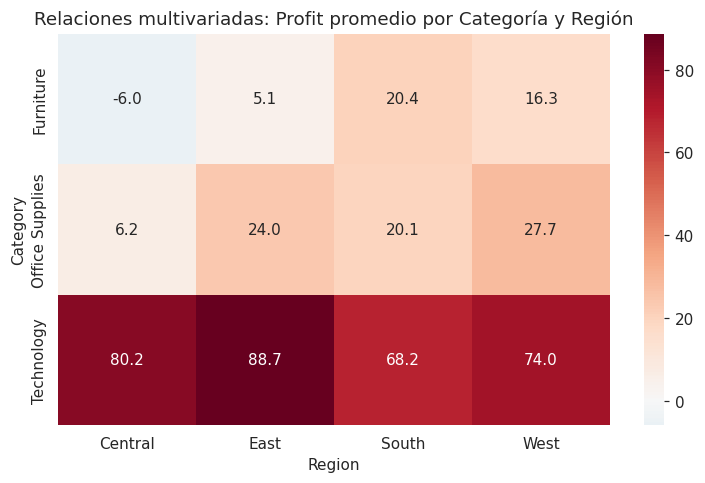

In [68]:
# Multivariado 1: Profit promedio por Categoría y Región (2 categóricas + 1 numérica)
tabla_profit = df.pivot_table(index="Category", columns="Region", values="Profit", aggfunc="mean")
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.heatmap(tabla_profit, annot=True, fmt=".1f", cmap="RdBu_r", center=0, ax=ax)
ax.set_title("Relaciones multivariadas: Profit promedio por Categoría y Región")
plt.tight_layout()
plt.show()

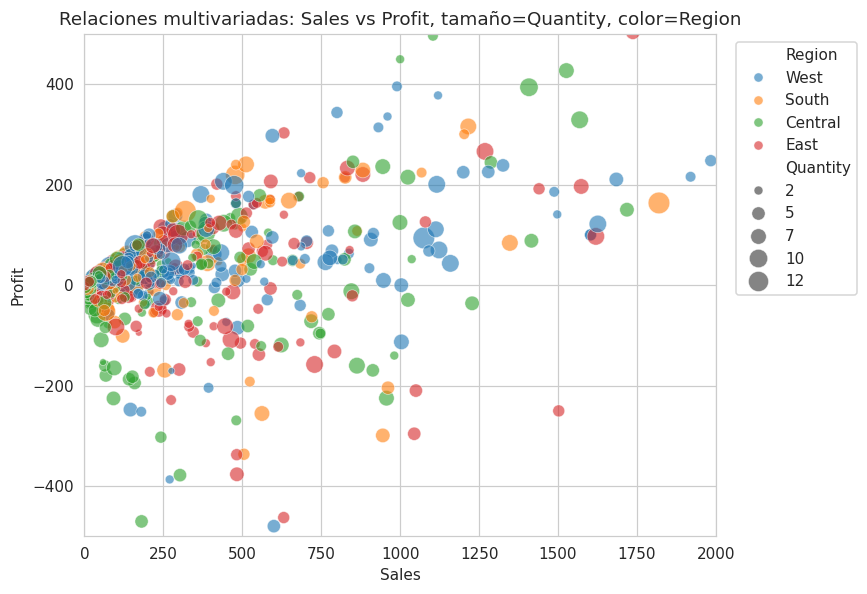

In [69]:
# Scatter multivariado: Sales vs Profit, tamaño=Quantity, color=Region (4 variables en un solo gráfico)
fig, ax = plt.subplots(figsize=(8, 5.5))
muestra = df.sample(1500, random_state=1)
sns.scatterplot(data=muestra, x="Sales", y="Profit", size="Quantity", hue="Region",
                 alpha=0.6, sizes=(20, 200), ax=ax)
ax.set_xlim(0, 2000)
ax.set_ylim(-500, 500)
ax.set_title("Relaciones multivariadas: Sales vs Profit, tamaño=Quantity, color=Region")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### 6.7 Eevolución temporal de Sales (la agrego porque me parece interesante su analisis)
Es probable que ese crecimiento en ventas que se observa obedezca a un contexto inflacionario y no necesarimente sea un reflejo de que las ventas crecen, de hecho en los boxplot se observan ganancias marginales escasas en la mayoria de los productos y perdidas considerables (bigotes negativos)

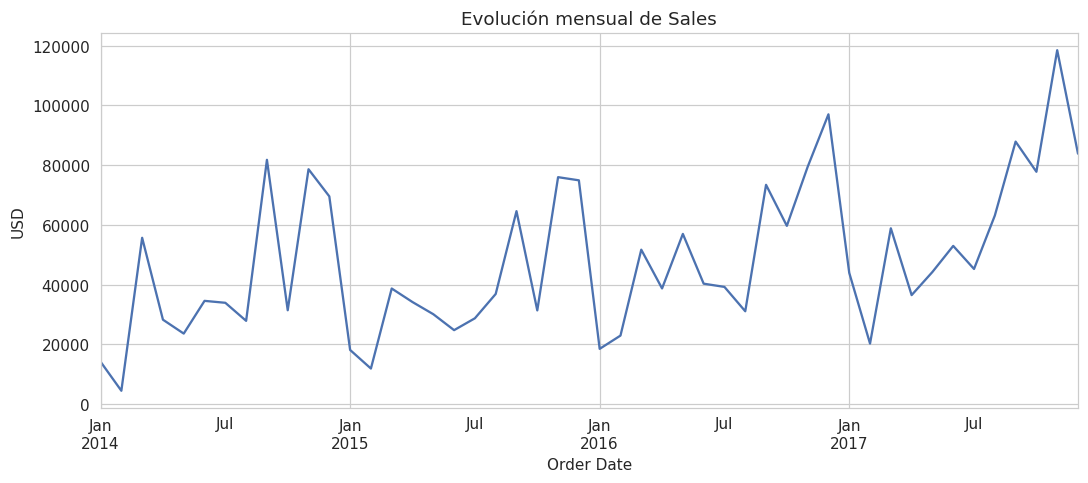

In [70]:
fig, ax = plt.subplots(figsize=(10, 4.5))
ventas_mes = df.set_index("Order Date")["Sales"].resample("ME").sum()
ventas_mes.plot(ax=ax, color="#4C72B0")
ax.set_title("Evolución mensual de Sales")
ax.set_ylabel("USD")
plt.tight_layout()
plt.show()


## 7. Tabla resumen por Sub-Categoría (ventas, ganancia y margen)

In [71]:
resumen_sub = df.groupby("Sub-Category").agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum"),
    Orders=("Order ID", "count")
).sort_values("Sales", ascending=False)
resumen_sub["Margin_%"] = (resumen_sub["Profit"] / resumen_sub["Sales"] * 100).round(1)
resumen_sub


,Sales,Profit,Orders,Margin_%
Sub-Category,,,,
Phones,330007.0540,44515.7306,889,13.5
Chairs,328449.1030,26590.1663,617,8.1
Storage,223843.6080,21278.8264,846,9.5
Tables,206965.5320,-17725.4811,319,-8.6
Binders,203412.7330,30221.7633,1523,14.9
Machines,189238.6310,3384.7569,115,1.8
Accessories,167380.3180,41936.6357,775,25.1
Copiers,149528.0300,55617.8249,68,37.2
Bookcases,114879.9963,-3472.5560,228,-3.0


## 8. Observaciones

- El dataset no tiene nulos ni duplicados (9994 filas, 21 columnas).
- `Sales` y `Profit` tienen asimetría positiva marcada y curtosis alta (colas pesadas):
  pocas transacciones muy grandes concentran gran parte del valor.
- el descuento que aplican a ciertos productos (`Discount`) correlaciona negativamente con `Profit` en las tres métricas (Pearson, Spearman
  y Kendall coinciden en signo), aunque la fuerza varía según se mida la relación como
  lineal (Pearson) o monótona/basada en rangos (Spearman, Kendall).
- `Ship Mode` (o modo de envio) es la única variable categórica con orden natural (ordinal); el resto son nominales.
- *Tables* y *Bookcases* muestran mediana de Profit negativa; *Copiers* y *Labels* tienen
  buen margen relativo pero bajo volumen de compras.

